## Generate CMIP Forcing data

- historcal only to 2014


In [1]:
# Ignore user warnings :)
import warnings

warnings.filterwarnings("ignore", category=UserWarning)

# Required dependencies
from pathlib import Path

import ewatercycle
import ewatercycle.forcing
import matplotlib.pyplot as plt
import xarray as xr
from rich import print

In [2]:
# The name of the shapefile
shape_file_name = "Kerki_GRDC"  # river: Bedford Ouse at Roxton, England

# The time-window of the experiment
experiment_start_date = "1950-01-01T00:00:00Z"
experiment_end_date = "2014-12-31T00:00:00Z"

forcing_path_CMIP = (
    Path.cwd() / ".." / ".." / "output" / "CMIP" / f"forcing_HBV_{shape_file_name}" / "CMIP6"
).resolve()

# The path save directory of the ERA5 data
# forcing_path_ERA5 = Path.home() / "projects/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/Aral_Test/forcing" / shape_file_name / "ERA5" / "own_shapefile"
# forcing_path_ERA5.mkdir(exist_ok=True)
forcing_path_CMIP.mkdir(parents=True, exist_ok=True)

In [3]:
shapefile_path = (
    Path.cwd()
    / ".."
    / ".."
    / ".."
    / "data"
    / "shapefiles"
    / shape_file_name
    / f"{shape_file_name}.shp"
).resolve()


print(shapefile_path)

/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/data/shapefiles
/Kerki_GRDC/Kerki_GRDC.shp

In [4]:
# # The name of the shapefile
# shape_file_name = "AralSeaBasin"  # river: Bedford Ouse at Roxton, England

# # The path to the shapefiles
# shapefile_path =  Path.cwd()/'AralSea_Basin'/ f"{shape_file_name}.shp"  # check this directory yourself!

# # The time-window of the experiment
# experiment_start_date = "2030-01-01T00:00:00Z"
# experiment_end_date = "2060-12-31T00:00:00Z"

# # The path save directory of the CMIP data
# forcing_path_CMIP = Path.cwd() / "forcing_CMIP_3060" / shape_file_name / "CMIP6"   # we do not use historical here, so we can use this as a default save path later on
# forcing_path_CMIP.mkdir(parents=True, exist_ok=True)



In [5]:
cmip_historical = {
    "project": "CMIP6",
    "exp": "historical",
    "dataset": "MPI-ESM1-2-HR",
    "ensemble": "r1i1p1f1",
    "grid": "gn",
}

# cmip_dataset =  {
#     'project': 'CMIP6',
#     'activity': 'ScenarioMIP',
#     'exp': 'ssp585',
#     'mip': 'day',
#     'dataset': 'EC-Earth3',
#     'ensemble': 'r1i1p1f1',
#     'grid': '*'
# }

CMIP_forcing = ewatercycle.forcing.sources["LumpedMakkinkForcing"].generate(
    dataset=cmip_historical,
    start_time=experiment_start_date,
    end_time=experiment_end_date,
    shape=shapefile_path,
    directory=forcing_path_CMIP / "historical" / "Lumped",
)

# CMIP_forcing = ewatercycle.forcing.sources["LumpedMakkinkForcing"].generate(
#    dataset=cmip_dataset,
#    start_time=experiment_start_date,
#    end_time=experiment_end_date,
#    shape=shapefile_path,
#    directory=forcing_path_CMIP / "future"/ "Lumped",
# )

In [6]:
# Load the generated historical data
historical_CMIP_location = (
    forcing_path_CMIP / "historical" / "Lumped" / "work" / "diagnostic" / "script"
)
historical_CMIP_forcing = ewatercycle.forcing.sources["LumpedMakkinkForcing"].load(
    directory=historical_CMIP_location
)

# load the generated future data
# future_CMIP_location = forcing_path_CMIP / "future"/ "Lumped" /"work" / "diagnostic" / "script"
# future_CMIP_forcing = ewatercycle.forcing.sources["LumpedMakkinkForcing"].load(directory=future_CMIP_location)

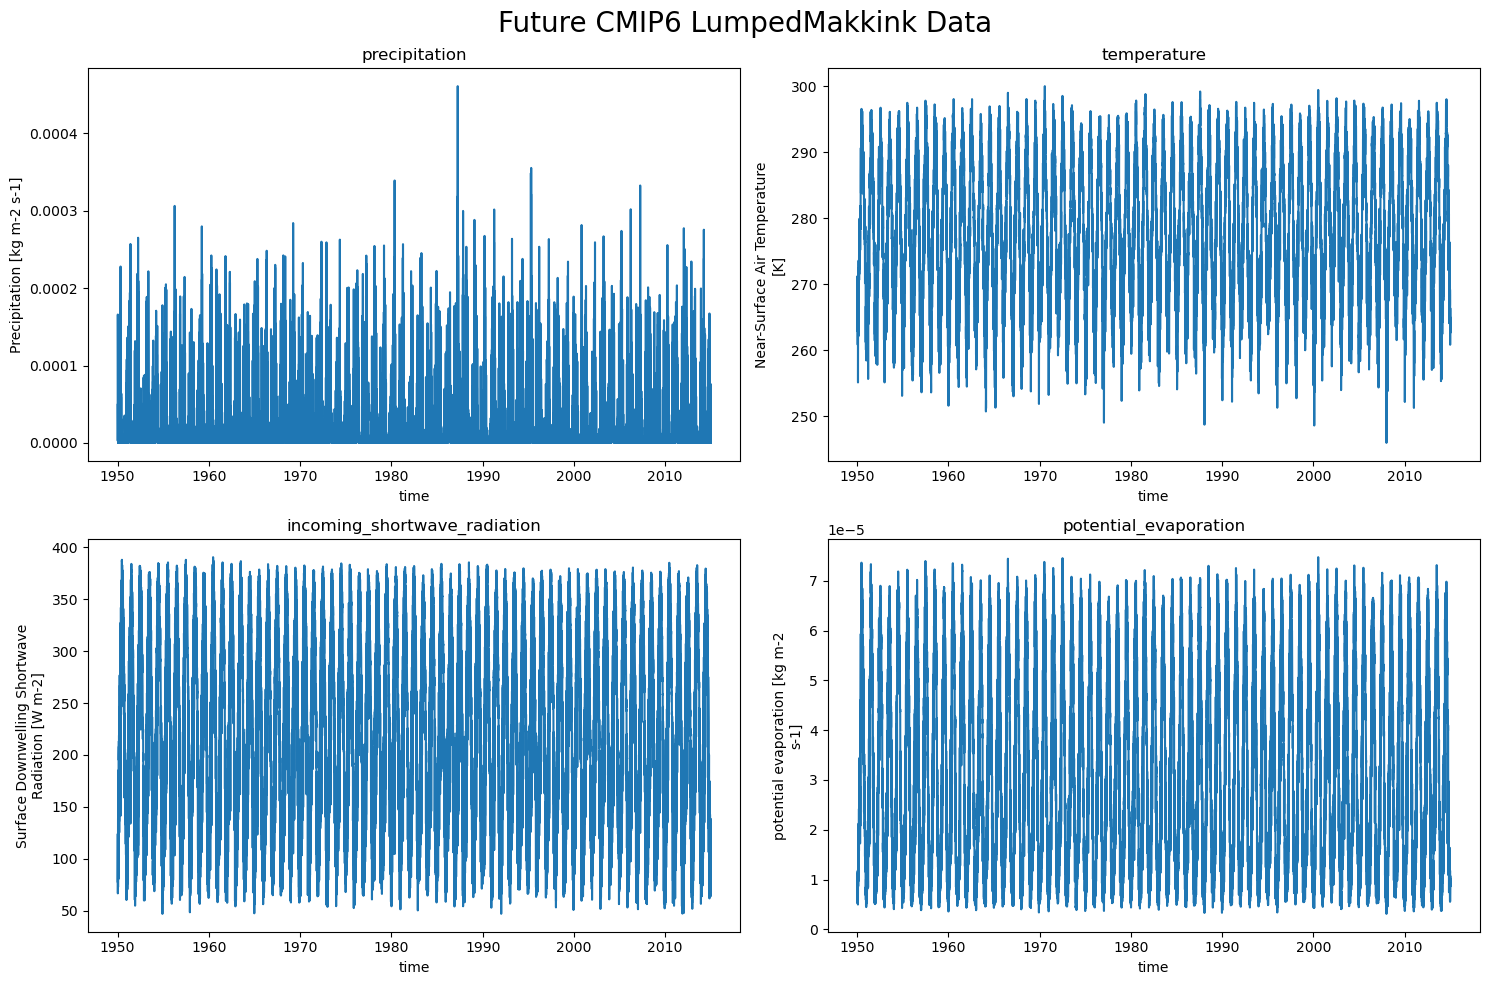

In [7]:
historical_data = {
    "precipitation pr": xr.open_dataset(historical_CMIP_forcing["pr"]),
    "temperature tas": xr.open_dataset(historical_CMIP_forcing["tas"]),
    "incoming_shortwave_radiation rsds": xr.open_dataset(historical_CMIP_forcing["rsds"]),
    "potential_evaporation evspsblpot": xr.open_dataset(historical_CMIP_forcing["evspsblpot"]),
}

plot_counter = 1
plt.figure(figsize=(15, 10))
for name, data in historical_data.items():
    plt.subplot(2, 2, plot_counter)
    data[name.split(" ")[-1]].plot()
    plt.title(f"{name.split(" ")[0]}")
    plot_counter += 1

plt.suptitle("Future CMIP6 LumpedMakkink Data", fontsize=20)
plt.tight_layout()

In [8]:
# future_data = {'precipitation pr': xr.open_dataset(future_CMIP_forcing['pr']),
#              'temperature tas': xr.open_dataset(future_CMIP_forcing['tas']),
#              'incoming_shortwave_radiation rsds': xr.open_dataset(future_CMIP_forcing['rsds']),
#              'potential_evaporation evspsblpot': xr.open_dataset(future_CMIP_forcing['evspsblpot'])
# }

# plot_counter = 1
# plt.figure(figsize=(15, 10))
# for name, data in future_data.items():
#     plt.subplot(2,2, plot_counter)
#     data[name.split(" ")[-1]].plot()
#     plt.title(f"{name.split(" ")[0]}")
#     plot_counter += 1

# plt.suptitle("Future CMIP6 LumpedMakkink Data", fontsize=20)
# plt.tight_layout()

